<a href="https://colab.research.google.com/github/RafaXzaviero/Sales-and-Marketing-Predictionapp/blob/main/UAS_BENGKOD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MEMBACA DATASET CSV DARI DIRECTORY

In [1]:
import pandas as pd

df = pd.read_csv('/content/Salesdataset.csv')

In [2]:
display(df.head())

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


## 1. Exploratory Data Analysis (EDA)

Let's begin by examining the basic information of the dataset, such as data types, non-null values, and memory usage, to get an initial understanding of its structure.

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [4]:
display(df.describe())

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


### Missing Values Analysis

Identifying and handling missing values is a crucial step in data preprocessing. We'll calculate the percentage of missing values for each column and visualize this to get a clear picture of data completeness.

In [5]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_percentage.index,
    'Missing Percentage': missing_percentage.values
}).sort_values(by='Missing Percentage', ascending=False)

# Filter out columns with no missing values for better visualization
missing_df = missing_df[missing_df['Missing Percentage'] > 0]

display(missing_df)

,Column,Missing Percentage
19,coupon_code,40.886667
2,age,8.000000
16,total_spent,7.000000
1,gender,4.920000
24,satisfaction_score,4.680000


/tmp/ipykernel_1145/427620406.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Missing Percentage', y='Column', data=missing_df, palette='viridis')


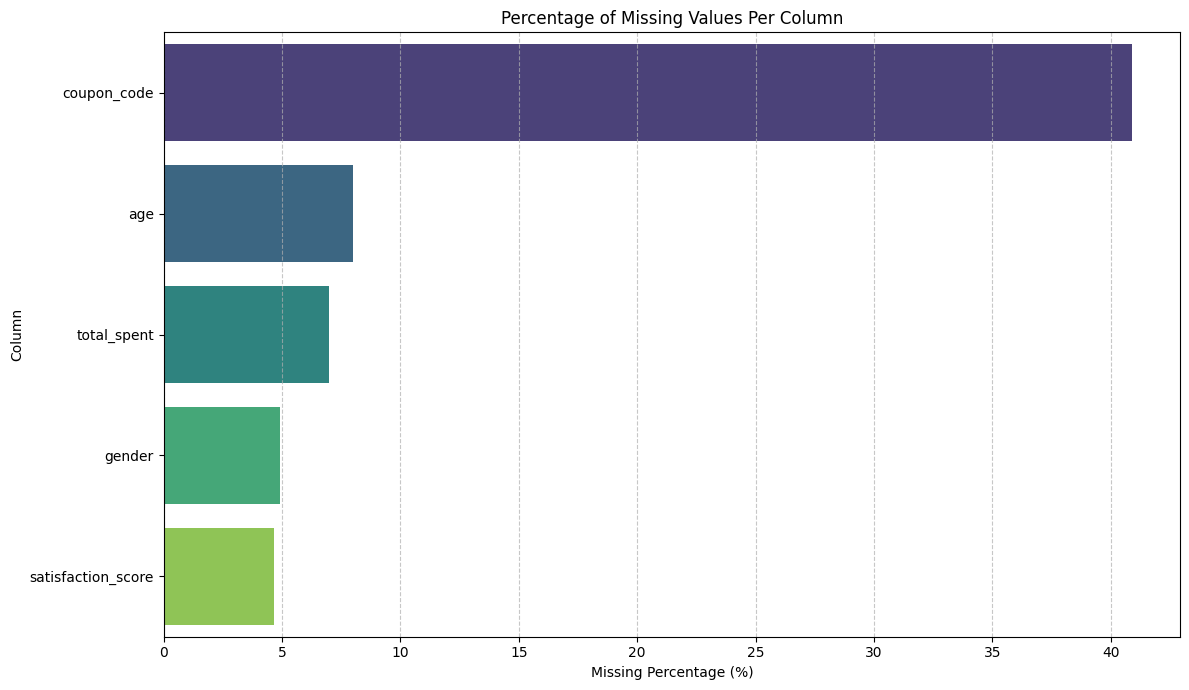

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

if not missing_df.empty:
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Missing Percentage', y='Column', data=missing_df, palette='viridis')
    plt.title('Percentage of Missing Values Per Column')
    plt.xlabel('Missing Percentage (%)')
    plt.ylabel('Column')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the dataset.')

### Target Variable Distribution (Churn)

Understanding the distribution of our target variable, 'churn', is crucial for identifying class imbalance, which can significantly impact model training. We'll visualize this distribution using a bar plot.

/tmp/ipykernel_1145/825579281.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='pastel')


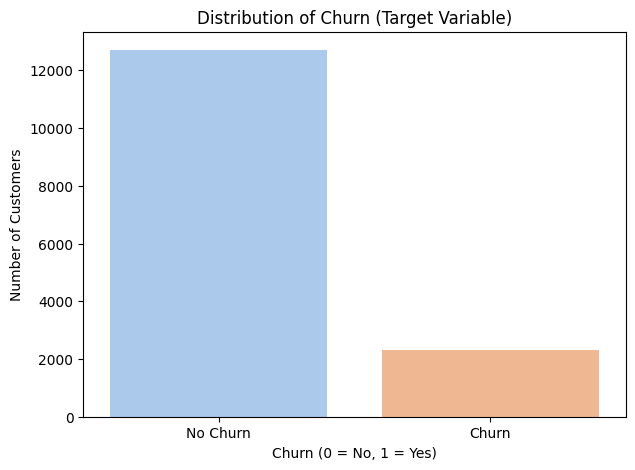

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='churn', data=df, palette='pastel')
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

### Correlation Heatmap of Numerical Features

A correlation heatmap allows us to visualize the Pearson correlation coefficients between all pairs of numerical features. This helps in understanding linearity, multicollinearity, and potential feature importance in relation to the target variable (`churn`).

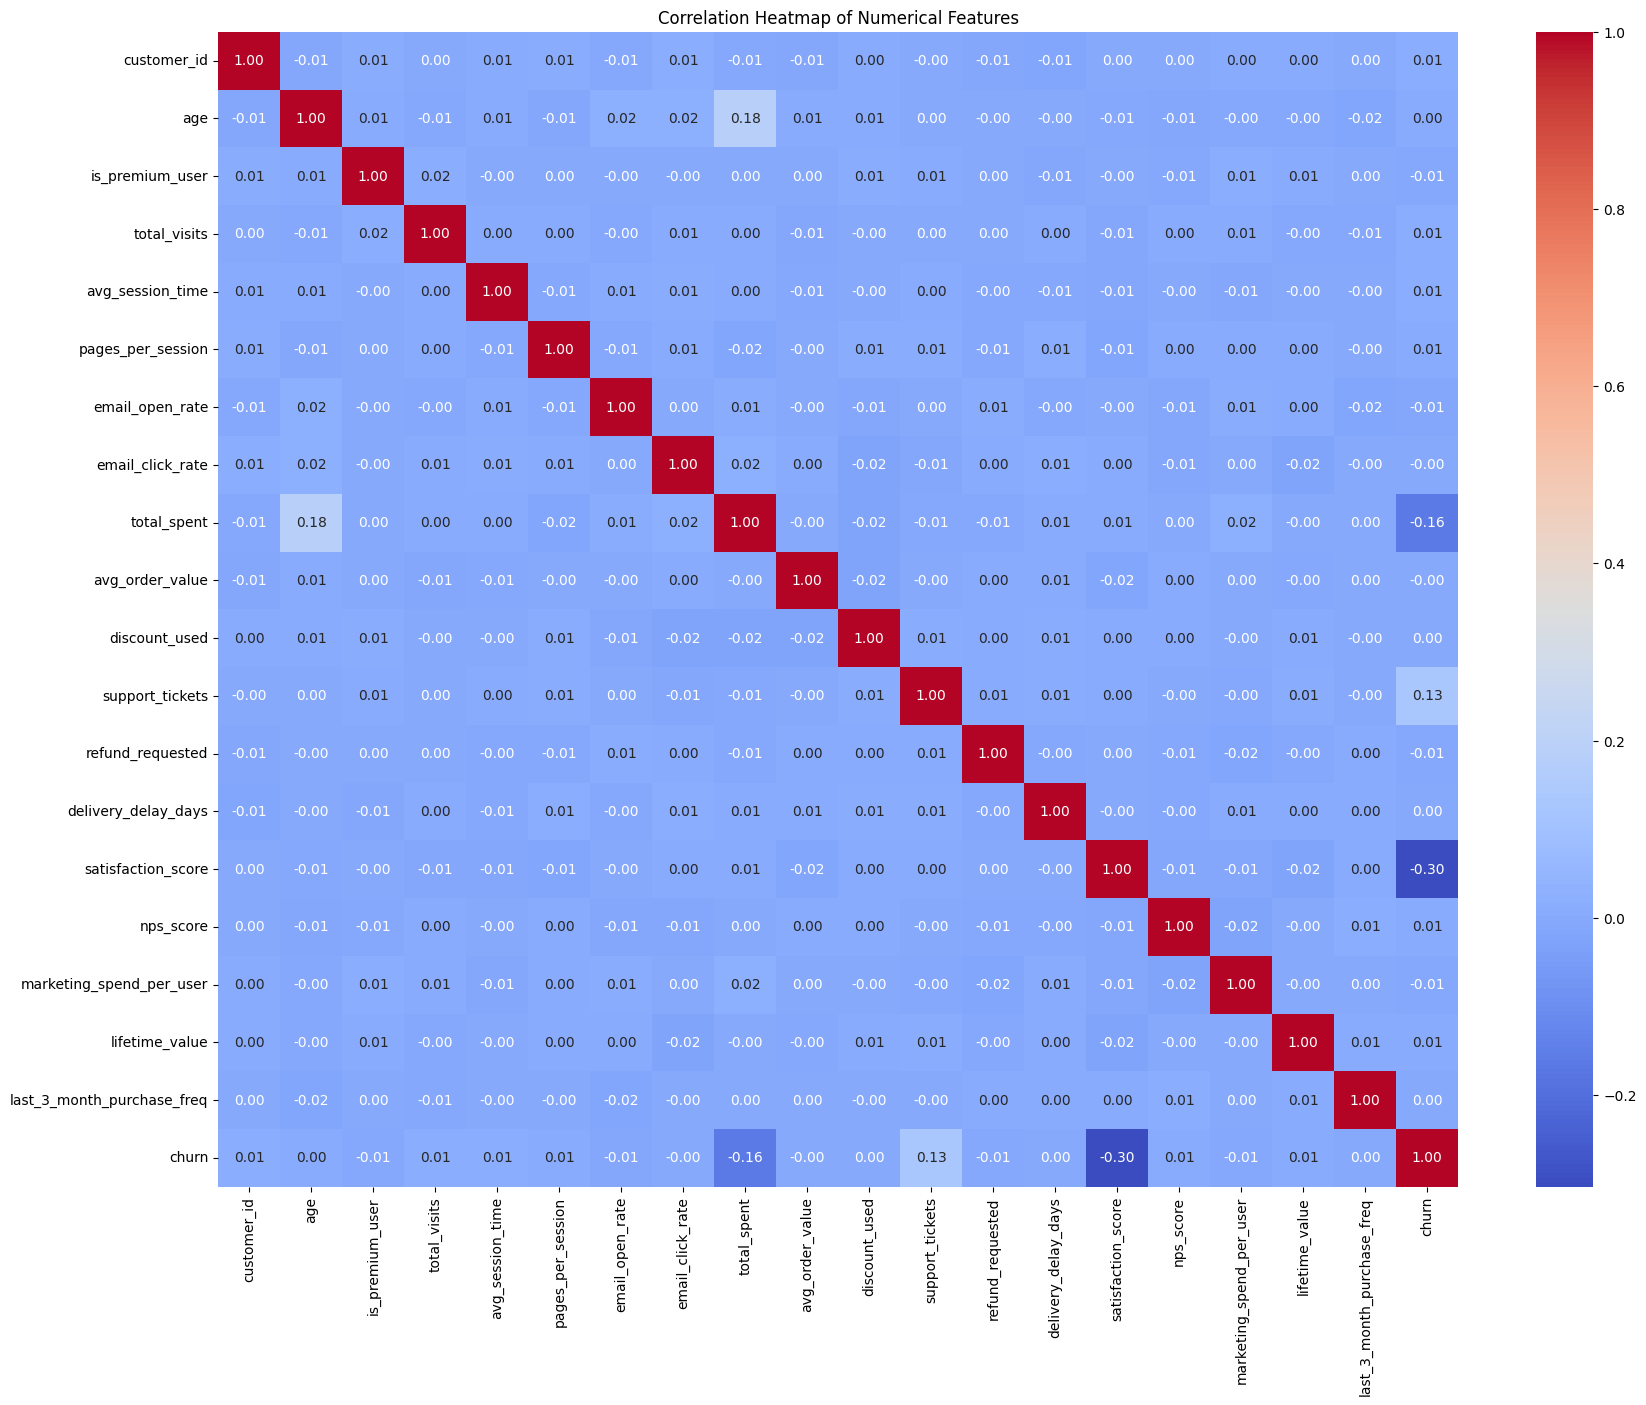

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation heatmap
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 15))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 2. Direct Modeling: Building Baseline Models

In this section, we will build baseline machine learning models directly on our prepared dataset, without extensive preprocessing or hyperparameter tuning. The objective is to establish initial performance metrics for different model categories.

### 2.1. Feature and Target Variable Definition

We will define `churn` as our target variable (`y`) and all other relevant columns as our feature set (`X`). For the 'Direct Modeling' phase, we'll perform necessary encoding for limited categorical features and make pragmatic decisions about high-cardinality and date columns to avoid complex preprocessing.

In [9]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define target variable (y)
y = df['churn']

# Define features (X)
# Drop 'churn' and 'customer_id' (identifier)
X = df.drop(['churn', 'customer_id'], axis=1)

# Identify categorical columns to encode
categorical_cols_to_encode = ['gender', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']

# Identify columns to drop (high cardinality or date strings for 'direct' modeling)
columns_to_drop_direct_modeling = ['country', 'city', 'signup_date', 'last_purchase_date']

# Apply one-hot encoding to selected categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols_to_encode, drop_first=True)

# Drop high cardinality/date columns from the encoded DataFrame
X_final = X_encoded.drop(columns=columns_to_drop_direct_modeling, errors='ignore')

# Combine X_final and y to identify all rows with any NaNs in either features or target.
# Then drop those rows from both X_final and y to ensure clean data for modeling.
initial_rows_count = X_final.shape[0] # Store initial row count for comparison

# Create a temporary DataFrame for combined NaN handling
# Use .copy() to avoid SettingWithCopyWarning if X_final is a slice
temp_X_final = X_final.copy()
temp_y = y.copy()

# Concatenate for combined NaN dropping
# Since y is a Series, it will be added as a column with its name 'churn'
combined_data = pd.concat([temp_X_final, temp_y], axis=1)

# Drop rows containing any NaN values from the combined data
combined_data_cleaned = combined_data.dropna()

# Separate X_final and y again
X_final = combined_data_cleaned.drop(columns=['churn'])
y = combined_data_cleaned['churn']

rows_dropped = initial_rows_count - X_final.shape[0]
print(f"Number of rows with NaN values (in X or y) dropped: {rows_dropped}")
print(f"Shape of features (X_final) after processing: {X_final.shape}")
print(f"Shape of target (y): {y.shape}")
display(X_final.head())

Number of rows with NaN values (in X or y) dropped: 2754
Shape of features (X_final) after processing: (12246, 33)
Shape of target (y): (12246,)


,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,...,acquisition_channel_Referral,device_type_Mobile,device_type_Tablet,subscription_type_Monthly,coupon_code_REF10,coupon_code_SALE15,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,0,...,False,False,True,False,False,False,False,False,False,True
1,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,1,...,False,False,False,True,False,False,False,False,False,False
2,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,0,...,False,True,False,False,False,False,False,False,False,True
3,36.0,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,0,...,False,False,True,False,False,False,False,True,False,False
4,29.0,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,1,...,True,True,False,True,False,False,False,False,False,False


### 2.2. Train-Test Split

Now, we'll split the data into training and testing sets to evaluate the models on unseen data. A common split ratio is 70% for training and 30% for testing.

In [10]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8572, 33)
X_test shape: (3674, 33)
y_train shape: (8572,)
y_test shape: (3674,)


### 2.3. Model Selection and Training (Direct)

We will select three models, one from each specified category, and train them directly on the `X_train` and `y_train` data. No preprocessing (like scaling) or hyperparameter tuning will be applied at this stage, as per the instructions for 'Direct Modeling'.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 1. Conventional Model: Logistic Regression
log_reg_direct = LogisticRegression(random_state=42, solver='liblinear')

# 2. Ensemble Bagging Model: Random Forest Classifier
rf_direct = RandomForestClassifier(random_state=42)

# 3. Ensemble Voting Classifier
# For VotingClassifier, ensure all estimators are of a similar scale or use scaling.
# However, for 'Direct Modeling' without preprocessing, we'll use base estimators as is.
# SVC can be slow, so for a quick 'direct' run, we might limit its parameters or choose a faster alternative if needed.
# Let's keep it simple for direct modeling.

estimators = [
    ('logistic', LogisticRegression(random_state=42, solver='liblinear')),
    ('knn', KNeighborsClassifier()),
    ('svc', SVC(probability=True, random_state=42))
]
voting_direct = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

print("Training Logistic Regression (Direct)... ")
log_reg_direct.fit(X_train, y_train)
print("Logistic Regression (Direct) trained.")

print("\nTraining Random Forest Classifier (Direct)... ")
rf_direct.fit(X_train, y_train)
print("Random Forest Classifier (Direct) trained.")

print("\nTraining Voting Classifier (Direct)... ")
voting_direct.fit(X_train, y_train)
print("Voting Classifier (Direct) trained.")

Training Logistic Regression (Direct)... 
Logistic Regression (Direct) trained.

Training Random Forest Classifier (Direct)... 
Random Forest Classifier (Direct) trained.

Training Voting Classifier (Direct)... 
Voting Classifier (Direct) trained.


### 2.4. Model Evaluation (Direct)

We will evaluate the performance of each trained model using accuracy, precision, recall, F1-score, and a confusion matrix. This provides a comprehensive view of how well each model predicts customer churn without any further preprocessing or hyperparameter tuning.


--- Logistic Regression (Direct) Performance ---
Accuracy: 0.8400
Precision: 0.4866
Recall: 0.1561
F1-Score: 0.2364


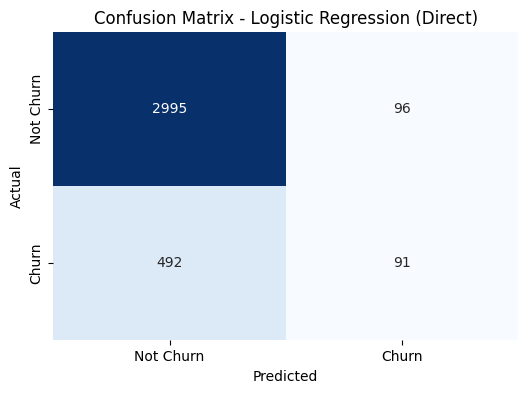


--- Random Forest Classifier (Direct) Performance ---
Accuracy: 0.8378
Precision: 0.4764
Recall: 0.2247
F1-Score: 0.3054


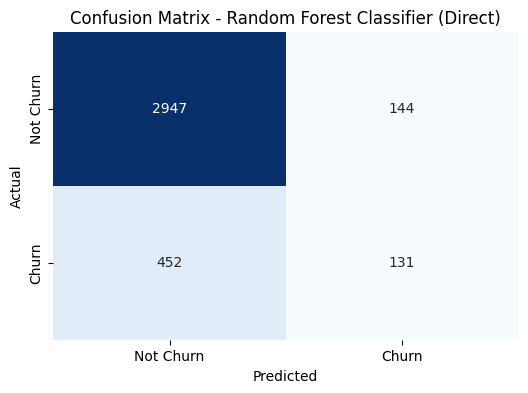


--- Voting Classifier (Direct) Performance ---
Accuracy: 0.8446
Precision: 0.6250
Recall: 0.0515
F1-Score: 0.0951


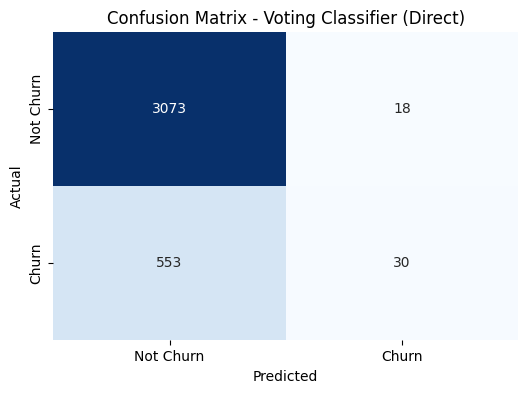

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate Logistic Regression
evaluate_model(log_reg_direct, X_test, y_test, "Logistic Regression (Direct)")

# Evaluate Random Forest
evaluate_model(rf_direct, X_test, y_test, "Random Forest Classifier (Direct)")

# Evaluate Voting Classifier
evaluate_model(voting_direct, X_test, y_test, "Voting Classifier (Direct)")

## 2. Modeling Dengan Preprocessing

This section focuses on building and evaluating models after applying a comprehensive preprocessing pipeline. This includes handling duplicates and outliers, encoding categorical features, scaling numerical features (after data splitting), and ensuring features are relevant for modeling.

### 2.1. Data Cleaning and Preprocessing Steps

First, we'll ensure the data is clean by checking for and handling any duplicate rows, and then address outliers in numerical features.

#### 2.1.1. Handling Duplicate Rows

Duplicate rows can lead to biased model training. We will check for and remove any exact duplicate entries in the DataFrame.

In [13]:
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")
print(f"DataFrame shape after dropping duplicates: {df.shape}")

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0
DataFrame shape after dropping duplicates: (15000, 30)


#### 2.1.2. Handling Outliers

Outliers can disproportionately affect model training. We will identify and handle outliers in numerical features using the Interquartile Range (IQR) method by capping them at the whiskers.

In [14]:
import numpy as np

# Select only numerical columns for outlier detection
numerical_cols_df = df.select_dtypes(include=['int64', 'float64']).columns

# Exclude 'customer_id' and 'churn' from outlier capping, as they are identifiers/target
numerical_cols_for_outliers = [col for col in numerical_cols_df if col not in ['customer_id', 'churn']]

def cap_outliers_iqr(df_col):
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_col.clip(lower=lower_bound, upper=upper_bound)

# Apply outlier capping to each relevant numerical column
for col in numerical_cols_for_outliers:
    df[col] = cap_outliers_iqr(df[col])

print("Outliers in numerical columns have been capped using the IQR method.")
display(df[numerical_cols_for_outliers].describe())

Outliers in numerical columns have been capped using the IQR method.


,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq
count,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.0,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,35.134638,0.304467,14.996600,8.018659,4.001775,0.496278,0.251231,511.381594,60.051118,0.494467,1.989067,0.0,2.964200,3.615086,4.968667,17.575238,1234.954347,6.975133
std,9.987708,0.460197,3.878057,2.985147,1.476347,0.290108,0.144689,279.592193,24.655961,0.499986,1.399289,0.0,1.671258,1.030244,3.155495,7.183437,655.237952,4.323443
min,7.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.0,0.000000,1.500000,0.000000,5.000000,0.368886,0.000000
25%,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.0,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000
50%,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.0,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000
75%,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.0,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000
max,63.000000,1.000000,27.000000,16.188132,8.052290,1.000000,0.500000,1305.343477,127.672408,1.000000,6.000000,0.0,7.000000,5.000000,10.000000,30.000000,3082.699120,14.000000


#### 2.1.3. Feature Engineering: Date and Categorical Columns

We will convert date columns to datetime objects and extract meaningful features. For other categorical features, we will apply one-hot encoding. High-cardinality categorical features like `country` and `city` will be handled carefully, or potentially dropped if not deemed relevant or too complex for basic preprocessing.

In [15]:
# Convert date columns to datetime objects
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

# Extract features from dates
df['signup_month'] = df['signup_date'].dt.month
df['signup_day_of_week'] = df['signup_date'].dt.dayofweek
df['last_purchase_month'] = df['last_purchase_date'].dt.month
df['last_purchase_day_of_week'] = df['last_purchase_date'].dt.dayofweek

# Calculate customer tenure in days
df['customer_tenure_days'] = (df['last_purchase_date'] - df['signup_date']).dt.days

# Drop original date columns as they've been featurized
df.drop(columns=['signup_date', 'last_purchase_date'], inplace=True)

print("Date columns processed and new features extracted.")

# Identify remaining categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# 'country' and 'city' have high cardinality. For this 'preprocessing' scenario,
# let's try to keep them for now but be mindful of the resulting number of features.
# 'coupon_code' was already filled with 'No Coupon' and is ready for OHE.

# Exclude 'customer_id' as it's an identifier
categorical_cols_to_encode = [col for col in categorical_cols if col not in ['customer_id']]

# Apply one-hot encoding
df_preprocessed = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

print("\nCategorical features encoded.")
print(f"DataFrame shape after date feature engineering and one-hot encoding: {df_preprocessed.shape}")
display(df_preprocessed.head())

Date columns processed and new features extracted.

Categorical features encoded.
DataFrame shape after date feature engineering and one-hot encoding: (15000, 50)


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,...,acquisition_channel_Referral,device_type_Mobile,device_type_Tablet,subscription_type_Monthly,coupon_code_REF10,coupon_code_SALE15,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,10001,52.0,1,7,13.903745,5.415164,0.67,0.26,559.524958,65.246704,...,False,False,True,False,False,False,False,False,False,True
1,10002,35.0,0,19,5.112528,5.352441,0.70,0.37,356.491344,48.473887,...,False,False,False,True,False,False,False,False,False,False
2,10003,27.0,1,18,9.742749,3.594719,0.47,0.44,689.332196,77.815371,...,False,True,False,False,False,False,False,False,False,True
3,10004,36.0,1,16,9.642654,2.949531,0.58,0.37,445.429636,71.712192,...,False,False,True,False,False,False,False,True,False,False
4,10005,29.0,0,12,7.791291,2.405539,0.05,0.16,686.286022,44.990246,...,True,True,False,True,False,False,False,False,False,False


### 2.2. Defining Features (X) and Target (y) & Train-Test Split (with Preprocessed Data)

After all preprocessing steps (handling missing values, duplicates, outliers, and feature engineering/encoding), we now re-define our feature matrix (`X`) and target vector (`y`). Following this, we perform the train-test split before scaling the numerical features.

In [16]:
from sklearn.model_selection import train_test_split
import pandas as pd # Ensure pandas is imported for dropna

# Define target variable (y)
y = df_preprocessed['churn']

# Define features (X) - dropping 'churn' and 'customer_id'
X = df_preprocessed.drop(['churn', 'customer_id'], axis=1)

# Combine X and y to identify all rows with any NaNs in either features or target.
# Then drop those rows from both X and y to ensure clean data for modeling.
initial_rows_count_preprocessed = X.shape[0] # Store initial row count for comparison

# Create a temporary DataFrame for combined NaN handling
temp_X_preprocessed = X.copy()
temp_y_preprocessed = y.copy()

# Concatenate for combined NaN dropping
combined_data_preprocessed = pd.concat([temp_X_preprocessed, temp_y_preprocessed], axis=1)

# Drop rows containing any NaN values from the combined data
combined_data_preprocessed_cleaned = combined_data_preprocessed.dropna()

# Separate X and y again
X = combined_data_preprocessed_cleaned.drop(columns=['churn'])
y = combined_data_preprocessed_cleaned['churn']

rows_dropped_preprocessed = initial_rows_count_preprocessed - X.shape[0]
print(f"Number of rows with NaN values (in X or y) dropped during preprocessing: {rows_dropped_preprocessed}")
print(f"Shape of features (X) after preprocessing and cleaning: {X.shape}")
print(f"Shape of target (y) after preprocessing and cleaning: {y.shape}")

# Perform train-test split with the same proportion as direct modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Number of rows with NaN values (in X or y) dropped during preprocessing: 2754
Shape of features (X) after preprocessing and cleaning: (12246, 48)
Shape of target (y) after preprocessing and cleaning: (12246,)

X_train shape: (8572, 48)
X_test shape: (3674, 48)
y_train shape: (8572,)
y_test shape: (3674,)


### 2.3. Feature Scaling (After Split)

Now that our data is split, we will apply `StandardScaler` to the numerical features of both the training and testing sets. This prevents data leakage from the test set into the training process.

In [17]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# These are typically continuous or discrete numerical features that are not one-hot encoded or binary.
# We need to be careful not to scale the binary/one-hot encoded features.

numerical_cols_to_scale = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Exclude any binary features (e.g., is_premium_user, discount_used, refund_requested) and new categorical features from date processing
# Let's filter out columns that are clearly one-hot encoded (e.g., have 'True'/'False' values or are derived from categorical columns).

# A more robust way to get numerical columns that *should* be scaled:
# Get all columns that are numerical (float or int) but not binary (0/1) AND not the new date features that are inherently counts/indices
# and are not one-hot encoded.

# Start with original numerical columns (excluding churn, customer_id)
original_numerical_features = ['age', 'total_visits', 'avg_session_time', 'pages_per_session',
                               'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value',
                               'support_tickets', 'delivery_delay_days', 'satisfaction_score', 'nps_score',
                               'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']

# Add newly engineered numerical features from dates
engineered_date_features = ['signup_month', 'signup_day_of_week', 'last_purchase_month', 'last_purchase_day_of_week', 'customer_tenure_days']

all_numerical_features = [col for col in original_numerical_features + engineered_date_features if col in X.columns]

# Exclude binary columns from scaling (these are usually 0 or 1)
binary_features_not_to_scale = ['is_premium_user', 'discount_used', 'refund_requested']

features_to_scale = [col for col in all_numerical_features if col not in binary_features_not_to_scale]

scaler = StandardScaler()

# Apply scaling to the identified numerical features in both training and testing sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("Numerical features scaled successfully after train-test split.")
display(X_train_scaled[features_to_scale].head())

Numerical features scaled successfully after train-test split.


,age,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,support_tickets,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,signup_month,signup_day_of_week,last_purchase_month,last_purchase_day_of_week,customer_tenure_days
1601,-1.126602,0.253897,-2.646193,0.126629,1.332161,0.960105,1.911408,-1.575185,1.414926,0.034700,-0.617886,1.261204,1.333828,1.500881,-1.390495,-0.936109,-0.504851,0.803923,1.008717,0.844591
10413,-1.126602,2.057686,1.933829,1.508011,0.295549,1.512025,1.078207,0.431824,-0.002729,1.234091,0.362951,-1.592401,1.165695,-0.275241,-0.928219,-0.936109,-0.504851,-0.877274,1.505370,1.264525
7658,0.878991,2.315370,-0.278884,1.026400,1.643144,1.236065,1.823573,-0.203235,2.123753,-0.564995,-0.617886,0.944137,1.243509,0.365687,-0.465943,-0.936109,-1.505912,0.523723,-0.481241,-0.333932
3873,-1.026323,-2.065261,1.229808,0.517026,1.504929,-1.523534,0.903370,-0.101240,0.706099,0.634396,1.343787,0.944137,1.428315,0.570751,-0.234805,-1.236634,1.497270,-1.437673,1.008717,-1.783381
5314,0.979271,-1.034525,-1.407106,-0.030919,0.433764,-1.178584,0.522199,-0.160762,-0.002729,0.634396,-2.089141,-0.007065,-0.561483,-1.372791,-0.465943,0.867043,1.497270,-1.437673,-0.977894,-0.409791


### 2.4. Model Training (with Preprocessed Data)

We will now train the same three categories of models (conventional, ensemble bagging, and ensemble voting) using the preprocessed and scaled data (`X_train_scaled`, `y_train`). As per the instructions, no hyperparameter tuning will be applied at this stage.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 1. Conventional Model: Logistic Regression
log_reg_preprocessed = LogisticRegression(random_state=42, solver='liblinear')

# 2. Ensemble Bagging Model: Random Forest Classifier
rf_preprocessed = RandomForestClassifier(random_state=42)

# 3. Ensemble Voting Classifier
# SVC can be sensitive to scaling, which we have now applied. We'll use default parameters.
estimators_preprocessed = [
    ('logistic', LogisticRegression(random_state=42, solver='liblinear')),
    ('knn', KNeighborsClassifier()),
    ('svc', SVC(probability=True, random_state=42))
]
voting_preprocessed = VotingClassifier(estimators=estimators_preprocessed, voting='soft', n_jobs=-1)

print("Training Logistic Regression (with Preprocessing)... ")
log_reg_preprocessed.fit(X_train_scaled, y_train)
print("Logistic Regression (with Preprocessing) trained.")

print("\nTraining Random Forest Classifier (with Preprocessing)... ")
rf_preprocessed.fit(X_train_scaled, y_train)
print("Random Forest Classifier (with Preprocessing) trained.")

print("\nTraining Voting Classifier (with Preprocessing)... ")
voting_preprocessed.fit(X_train_scaled, y_train)
print("Voting Classifier (with Preprocessing) trained.")

Training Logistic Regression (with Preprocessing)... 
Logistic Regression (with Preprocessing) trained.

Training Random Forest Classifier (with Preprocessing)... 
Random Forest Classifier (with Preprocessing) trained.

Training Voting Classifier (with Preprocessing)... 
Voting Classifier (with Preprocessing) trained.


### 2.5. Model Evaluation (with Preprocessed Data)

After training, we will evaluate the performance of each model using accuracy, precision, recall, F1-score, and a confusion matrix on the scaled test set (`X_test_scaled`, `y_test`). This will allow us to compare the impact of preprocessing on model performance.


--- Logistic Regression (Preprocessed) Performance ---
Accuracy: 0.8446
Precision: 0.5337
Recall: 0.1630
F1-Score: 0.2497


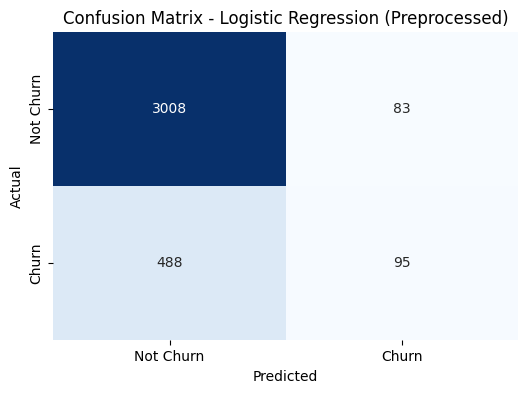


--- Random Forest Classifier (Preprocessed) Performance ---
Accuracy: 0.8391
Precision: 0.4762
Recall: 0.1372
F1-Score: 0.2130


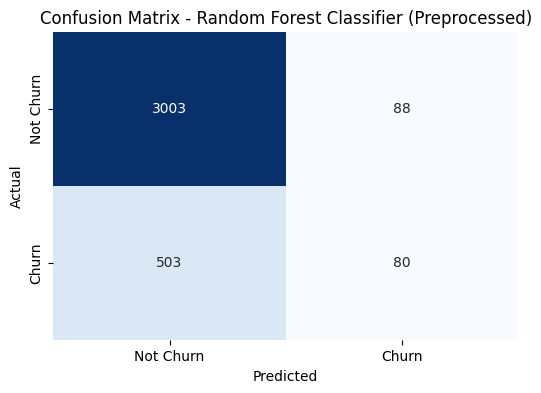


--- Voting Classifier (Preprocessed) Performance ---
Accuracy: 0.8394
Precision: 0.4745
Recall: 0.1115
F1-Score: 0.1806


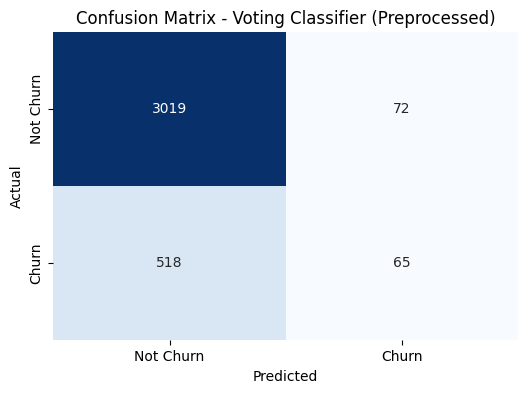

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Re-using the evaluate_model function defined earlier
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate Logistic Regression (with Preprocessing)
evaluate_model(log_reg_preprocessed, X_test_scaled, y_test, "Logistic Regression (Preprocessed)")

# Evaluate Random Forest Classifier (with Preprocessing)
evaluate_model(rf_preprocessed, X_test_scaled, y_test, "Random Forest Classifier (Preprocessed)")

# Evaluate Voting Classifier (with Preprocessing)
evaluate_model(voting_preprocessed, X_test_scaled, y_test, "Voting Classifier (Preprocessed)")

## 3. Pengoptimalan Model dengan Hyperparameter Tuning

In this section, we will optimize the performance of our selected models by fine-tuning their hyperparameters. This is expected to yield better performance than the direct and preprocessed models, especially in handling challenges like class imbalance.

### 3.1. Hyperparameter Tuning for Logistic Regression

We will use `GridSearchCV` to find the optimal hyperparameters for the Logistic Regression model, aiming to improve its predictive performance.

Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearchCV for Logistic Regression completed.

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}

--- Logistic Regression (Tuned) Performance ---
Accuracy: 0.8446
Precision: 0.5337
Recall: 0.1630
F1-Score: 0.2497


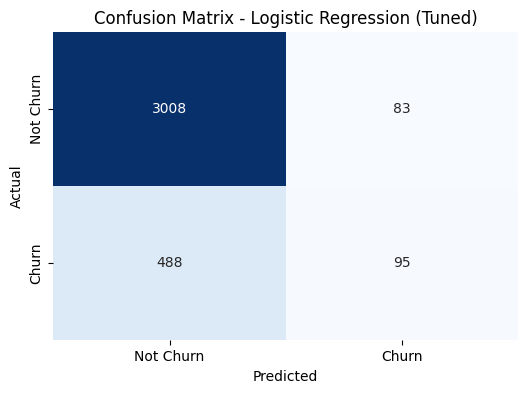

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Initialize Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, scoring='f1', n_jobs=-1, verbose=1)

print("Starting GridSearchCV for Logistic Regression...")
grid_search_lr.fit(X_train_scaled, y_train)
print("GridSearchCV for Logistic Regression completed.")

# Get the best estimator
best_lr_tuned = grid_search_lr.best_estimator_

print("\nBest parameters for Logistic Regression:", grid_search_lr.best_params_)

# Evaluate the best Logistic Regression model
evaluate_model(best_lr_tuned, X_test_scaled, y_test, "Logistic Regression (Tuned)")

### 3.2. Hyperparameter Tuning for Random Forest Classifier

We will use `GridSearchCV` to find the optimal hyperparameters for the Random Forest Classifier, aiming to improve its predictive performance.

Starting GridSearchCV for Random Forest Classifier...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
GridSearchCV for Random Forest Classifier completed.

Best parameters for Random Forest Classifier: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

--- Random Forest Classifier (Tuned) Performance ---
Accuracy: 0.8416
Precision: 0.5025
Recall: 0.1732
F1-Score: 0.2577


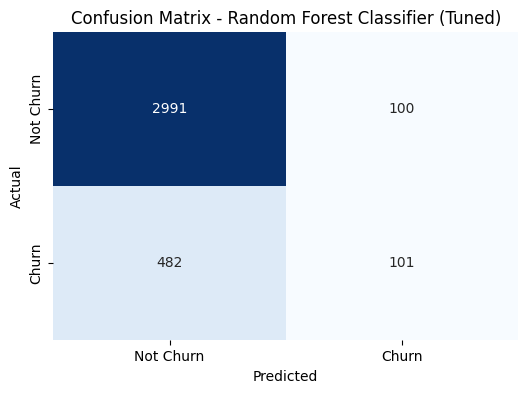

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for Random Forest Classifier
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Random Forest Classifier model
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=1)

print("Starting GridSearchCV for Random Forest Classifier...")
grid_search_rf.fit(X_train_scaled, y_train)
print("GridSearchCV for Random Forest Classifier completed.")

# Get the best estimator
best_rf_tuned = grid_search_rf.best_estimator_

print("\nBest parameters for Random Forest Classifier:", grid_search_rf.best_params_)

# Evaluate the best Random Forest Classifier model
evaluate_model(best_rf_tuned, X_test_scaled, y_test, "Random Forest Classifier (Tuned)")

### 3.3. Hyperparameter Tuning for K-Nearest Neighbors (KNN) Classifier

We will use `GridSearchCV` to find the optimal hyperparameters for the K-Nearest Neighbors Classifier, an important component of our Voting Classifier, to enhance its performance.

Starting GridSearchCV for KNeighborsClassifier...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV for KNeighborsClassifier completed.

Best parameters for KNeighborsClassifier: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}

--- KNeighborsClassifier (Tuned) Performance ---
Accuracy: 0.8285
Precision: 0.3956
Recall: 0.1527
F1-Score: 0.2203


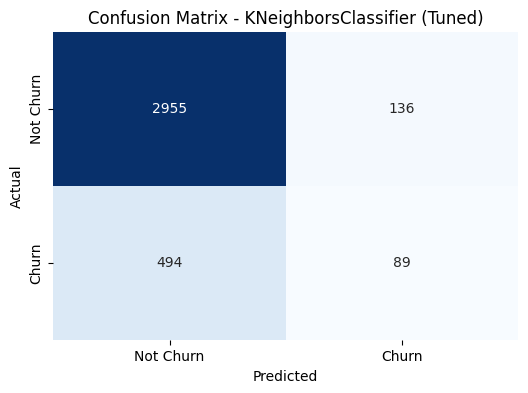

In [22]:
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for KNeighborsClassifier
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize KNeighborsClassifier model
knn = KNeighborsClassifier()

# Initialize GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, scoring='f1', n_jobs=-1, verbose=1)

print("Starting GridSearchCV for KNeighborsClassifier...")
grid_search_knn.fit(X_train_scaled, y_train)
print("GridSearchCV for KNeighborsClassifier completed.")

# Get the best estimator
best_knn_tuned = grid_search_knn.best_estimator_

print("\nBest parameters for KNeighborsClassifier:", grid_search_knn.best_params_)

# Evaluate the best KNeighborsClassifier model
evaluate_model(best_knn_tuned, X_test_scaled, y_test, "KNeighborsClassifier (Tuned)")

### 3.4. Hyperparameter Tuning for Support Vector Classifier (SVC)

We will now perform hyperparameter tuning for the Support Vector Classifier (SVC), which is another component of our Voting Classifier. This will help us find the best configuration for SVC before integrating it into the ensemble.

Starting GridSearchCV for SVC...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
GridSearchCV for SVC completed.

Best parameters for SVC: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

--- Support Vector Classifier (Tuned) Performance ---
Accuracy: 0.8217
Precision: 0.4291
Recall: 0.3739
F1-Score: 0.3996


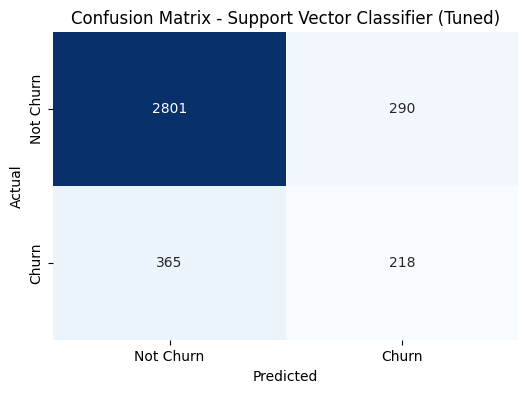

In [23]:
from sklearn.svm import SVC

# Define the parameter grid for SVC
# Due to the computational cost of SVC, we will use a smaller, more focused grid.
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Initialize SVC model
svc = SVC(probability=True, random_state=42)

# Initialize GridSearchCV
grid_search_svc = GridSearchCV(estimator=svc, param_grid=param_grid_svc, cv=3, scoring='f1', n_jobs=-1, verbose=1) # Reduced CV folds to 3 for faster execution

print("Starting GridSearchCV for SVC...")
grid_search_svc.fit(X_train_scaled, y_train)
print("GridSearchCV for SVC completed.")

# Get the best estimator
best_svc_tuned = grid_search_svc.best_estimator_

print("\nBest parameters for SVC:", grid_search_svc.best_params_)

# Evaluate the best SVC model
evaluate_model(best_svc_tuned, X_test_scaled, y_test, "Support Vector Classifier (Tuned)")

### 3.5. Hyperparameter Tuning for Voting Classifier

Now that we have tuned the individual base models (Logistic Regression, Random Forest, KNN, and SVC), we will assemble them into a Voting Classifier. We will then perform hyperparameter tuning on the weights of the Voting Classifier to find the optimal combination that maximizes overall performance.

Starting GridSearchCV for Voting Classifier...
Fitting 3 folds for each of 7 candidates, totalling 21 fits
GridSearchCV for Voting Classifier completed.

Best parameters for Voting Classifier: {'weights': [1, 1, 1, 2]}

--- Voting Classifier (Tuned) Performance ---
Accuracy: 0.8413
Precision: 0.5000
Recall: 0.1235
F1-Score: 0.1981


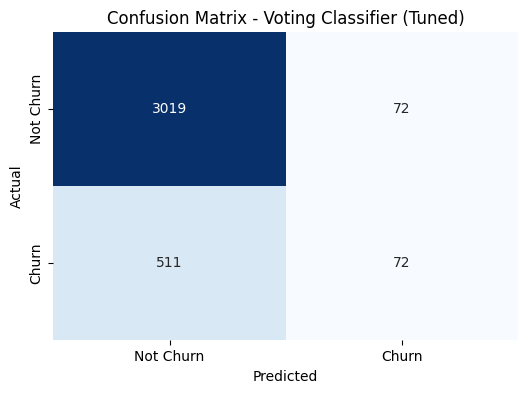

In [24]:
from sklearn.ensemble import VotingClassifier

# Initialize the Voting Classifier with the best tuned individual estimators
# Ensure `best_lr_tuned`, `best_rf_tuned`, `best_knn_tuned`, and `best_svc_tuned` are defined from previous steps
voting_clf = VotingClassifier(
    estimators=[
        ('lr', best_lr_tuned),
        ('rf', best_rf_tuned),
        ('knn', best_knn_tuned),
        ('svc', best_svc_tuned)
    ],
    voting='soft', # Use 'soft' voting for probability-based prediction
    n_jobs=-1
)

# Define a parameter grid for the Voting Classifier weights
# The sum of weights should typically be 1 or adjusted based on preferences.
# For simplicity, we'll try different combinations of relative weights.
# Note: This can become computationally expensive with many base estimators.
param_grid_voting = {
    'weights': [
        [1, 1, 1, 1], # Equal weights
        [2, 1, 1, 1], # Higher weight for LR
        [1, 2, 1, 1], # Higher weight for RF
        [1, 1, 2, 1], # Higher weight for KNN
        [1, 1, 1, 2], # Higher weight for SVC
        [2, 2, 1, 1], # LR and RF slightly higher
        [1, 1, 2, 2]  # KNN and SVC slightly higher
    ]
}

# Initialize GridSearchCV for the Voting Classifier
grid_search_voting = GridSearchCV(estimator=voting_clf, param_grid=param_grid_voting, cv=3, scoring='f1', n_jobs=-1, verbose=1)

print("Starting GridSearchCV for Voting Classifier...")
grid_search_voting.fit(X_train_scaled, y_train)
print("GridSearchCV for Voting Classifier completed.")

# Get the best estimator
best_voting_tuned = grid_search_voting.best_estimator_

print("\nBest parameters for Voting Classifier:", grid_search_voting.best_params_)

# Evaluate the best Voting Classifier model
evaluate_model(best_voting_tuned, X_test_scaled, y_test, "Voting Classifier (Tuned)")